In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import pandas as pd
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)


2.13.0+cpu
0.28.0+cpu


In [2]:
train_data = pd.read_csv("../data/fashionmnist/fashion-mnist_train.csv")
test_data = pd.read_csv("../data/fashionmnist/fashion-mnist_test.csv")


len(train_data), len(test_data)

(60000, 10000)

In [3]:
train_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
train_data.value_counts()

label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  pixel10  pixel11  pixel12  pixel13  pixel14  pixel15  pixel16  pixel17  pixel18  pixel19  pixel20  pixel21  pixel22  pixel23  pixel24  pixel25  pixel26  pixel27  pixel28  pixel29  pixel30  pixel31  pixel32  pixel33  pixel34  pixel35  pixel36  pixel37  pixel38  pixel39  pixel40  pixel41  pixel42  pixel43  pixel44  pixel45  pixel46  pixel47  pixel48  pixel49  pixel50  pixel51  pixel52  pixel53  pixel54  pixel55  pixel56  pixel57  pixel58  pixel59  pixel60  pixel61  pixel62  pixel63  pixel64  pixel65  pixel66  pixel67  pixel68  pixel69  pixel70  pixel71  pixel72  pixel73  pixel74  pixel75  pixel76  pixel77  pixel78  pixel79  pixel80  pixel81  pixel82  pixel83  pixel84  pixel85  pixel86  pixel87  pixel88  pixel89  pixel90  pixel91  pixel92  pixel93  pixel94  pixel95  pixel96  pixel97  pixel98  pixel99  pixel100  pixel101  pixel102  pixel103  pixel104  pixel105  pixel106  pixel107  pixel108  pixel109  pixel110  p

In [ ]:
train_data.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='str', length=785)

In [4]:
train_data["label"].value_counts()

label
2    6000
9    6000
6    6000
0    6000
3    6000
4    6000
5    6000
8    6000
7    6000
1    6000
Name: count, dtype: int64

In [11]:
train_data.shape, test_data.shape

((60000, 785), (10000, 785))

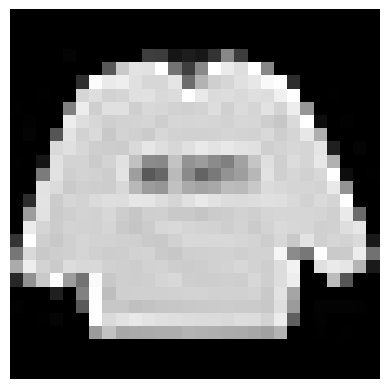

In [26]:
# Visualiser la premiere image first l'image est (784,)
image = train_data.iloc[0, 1:].values

# Transformer 784 pixels en 28 x 28
image = image.reshape(28, 28)

# Afficher l'Image apres reshape
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [45]:
# transformer pandas.Dataframe type to numpy.ndarray

X_train = train_data.iloc[:, 1:].to_numpy()
X_test = test_data.iloc[:, 1:].to_numpy()

y_train = train_data.iloc[:, 0].to_numpy()
y_test = test_data.iloc[:, 0].to_numpy()


In [46]:
# normaliser le tableau

X_train = X_train/255.0
X_test = X_test/255.0

In [47]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [48]:
type(X_train)


numpy.ndarray

In [83]:
# transformer en tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

type(X_train)

C:\Users\Ndagano\AppData\Local\Temp\ipykernel_19908\211436223.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\Ndagano\AppData\Local\Temp\ipykernel_19908\211436223.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)
C:\Users\Ndagano\AppData\Local\Temp\ipykernel_19908\211436223.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.long)
C:\Users\Ndagano\AppData\Local\Temp\ipykernel_19

torch.Tensor

In [84]:
X_train

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [108]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train, y_train)
test_dataset =  TensorDataset(X_test, y_test)

X_train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
X_test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

X_train_dataloader, X_test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x27507987e30>,
 <torch.utils.data.dataloader.DataLoader at 0x275569534a0>)

In [102]:
train_dataset

In [87]:
print(f"Train Dataloader length: {len(X_train_dataloader)} batches of {BATCH_SIZE} ...")
print(f"Test Dataloader length: {len(X_test_dataloader)} batches of {BATCH_SIZE} ...")

Train Dataloader length: 1875 batches of 32 ...
Test Dataloader length: 313 batches of 32 ...


In [88]:
X_train.shape

torch.Size([60000, 784])

In [109]:
class FashionMNISTModelVO(nn.Module):
    def __init__(self, input_shape:int, hidden_units: int, output_shape: int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [90]:
X_train.shape

torch.Size([60000, 784])

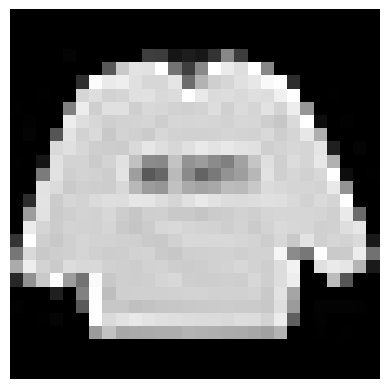

In [91]:
image = X_train[0].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [92]:
y_train

tensor([2, 9, 6,  ..., 8, 8, 7])

In [93]:
len(y_train.unique())

10

In [110]:
torch.manual_seed(42)

model_0 = FashionMNISTModelVO(
    input_shape=784,
    hidden_units=10,
    output_shape=len(y_train.unique())
)

model_0

FashionMNISTModelVO(
  (layer_stack): Sequential(
    (0): Linear(in_features=784, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [95]:
dummy_x = torch.rand([28, 28])

dummy_x = dummy_x.flatten()
dummy_x.shape

torch.Size([784])

In [96]:
model_0(dummy_x)

tensor([-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
        -0.1004,  0.0157], grad_fn=<ViewBackward0>)

In [97]:
model_0.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.0.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.1.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [114]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [115]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [116]:
from tqdm import tqdm

torch.manual_seed(42)
start_time = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n------")

    train_loss = 0

    for batch, (X, y) in enumerate(X_train_dataloader):
        model_0.train()

        y_pred = model_0(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(X_train_dataloader.dataset)} samples.")
    train_loss /= len(X_train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in X_test_dataloader:
            test_pred = model_0(X_test)

            test_loss += loss_fn(test_pred, y_test)

            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

        test_loss /= len(X_test_dataloader)

        test_acc /= len(X_test_dataloader)


    print(f"\nTrain loss {train_loss:.4f} | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

end_timer = timer()
print_train_time(start=start_time, end=end_timer, device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 33%|███▎      | 1/3 [00:10<00:20, 10.39s/it]


Train loss 0.5915 | Test loss: 0.5270, Test acc: 81.0104
Epoch: 1
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 67%|██████▋   | 2/3 [00:21<00:10, 10.81s/it]


Train loss 0.4803 | Test loss: 0.4624, Test acc: 84.2452
Epoch: 2
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 3/3 [00:34<00:00, 11.65s/it]


Train loss 0.4569 | Test loss: 0.4830, Test acc: 83.8558
Train time on cpu: 34.951 seconds


34.95089860004373